In [1]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import scienceplots

plt.style.use('science')

In [3]:
with h5.File("../data/condensate_showcase.h5", "r") as fid:
    t_skip = 100
    lattices = fid["group_test/lattice"][::t_skip, :]
    L = fid["group_test"].attrs["L"]
    t = fid["group_test"].attrs["t"]

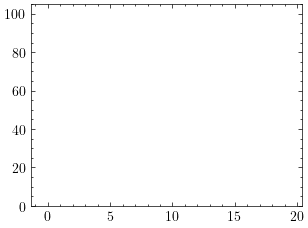

In [ ]:
fig, ax = plt.subplots()

artists = []
for ti in range(t//t_skip):
    container = ax.bar(range(L), (lattices[ti]), color="C0")
    artists.append(container)

ani = animation.ArtistAnimation(fig=fig, artists=artists, interval=100)
ani.save(filename="../data/condensate_vid.mp4", writer="ffmpeg")

## Evan's Plot

In [7]:
def occupation_prob(lattices, N):
    prob = np.zeros(N)
    t, L = lattices.shape
    for lattice in lattices:
        for x in lattice:
            prob[x] += 1

    prob /= np.sum(prob)
    return prob

In [8]:
probs = []
files = ["../data/evans_plot_low_density.h5", 
         "../data/evans_plot_high_density.h5"]

for file in files:
    with h5.File(file, "r") as fid:
        lattices = fid["group_test/lattice"][::1, :]
        N = fid['group_test'].attrs["N"]

        prob = occupation_prob(lattices, N)
        probs.append(prob)
    

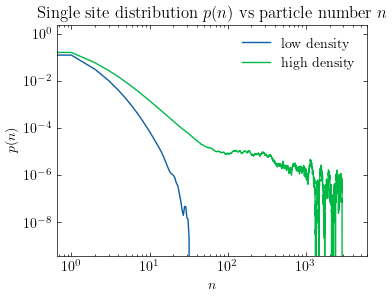

In [37]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.loglog(probs[0], lw=1, marker='', label="low density")
ax.loglog(probs[1], lw=1, marker='', label="high density")
ax.set_xlabel("$n$")
ax.set_ylabel("$p(n)$")
ax.set_title("Single site distribution $p(n)$ vs particle number $n$")
ax.legend()
fig.savefig("../data/evans_plot.pdf", format="pdf")